# Hello, KAN!

### Kolmogorov-Arnold representation theorem

Kolmogorov-Arnold representation theorem states that if $f$ is a multivariate continuous function
on a bounded domain, then it can be written as a finite composition of continuous functions of a
single variable and the binary operation of addition. More specifically, for a smooth $f : [0,1]^n \to \mathbb{R}$,


$$f(x) = f(x_1,...,x_n)=\sum_{q=1}^{2n+1}\Phi_q(\sum_{p=1}^n \phi_{q,p}(x_p))$$

where $\phi_{q,p}:[0,1]\to\mathbb{R}$ and $\Phi_q:\mathbb{R}\to\mathbb{R}$. In a sense, they showed that the only true multivariate function is addition, since every other function can be written using univariate functions and sum. However, this 2-Layer width-$(2n+1)$ Kolmogorov-Arnold representation may not be smooth due to its limited expressive power. We augment its expressive power by generalizing it to arbitrary depths and widths.

### Kolmogorov-Arnold Network (KAN)

The Kolmogorov-Arnold representation can be written in matrix form

$$f(x)={\bf \Phi}_{\rm out}\circ{\bf \Phi}_{\rm in}\circ {\bf x}$$

where 

$${\bf \Phi}_{\rm in}= \begin{pmatrix} \phi_{1,1}(\cdot) & \cdots & \phi_{1,n}(\cdot) \\ \vdots & & \vdots \\ \phi_{2n+1,1}(\cdot) & \cdots & \phi_{2n+1,n}(\cdot) \end{pmatrix},\quad {\bf \Phi}_{\rm out}=\begin{pmatrix} \Phi_1(\cdot) & \cdots & \Phi_{2n+1}(\cdot)\end{pmatrix}$$

We notice that both ${\bf \Phi}_{\rm in}$ and ${\bf \Phi}_{\rm out}$ are special cases of the following function matrix ${\bf \Phi}$ (with $n_{\rm in}$ inputs, and $n_{\rm out}$ outputs), we call a Kolmogorov-Arnold layer:

$${\bf \Phi}= \begin{pmatrix} \phi_{1,1}(\cdot) & \cdots & \phi_{1,n_{\rm in}}(\cdot) \\ \vdots & & \vdots \\ \phi_{n_{\rm out},1}(\cdot) & \cdots & \phi_{n_{\rm out},n_{\rm in}}(\cdot) \end{pmatrix}$$

${\bf \Phi}_{\rm in}$ corresponds to $n_{\rm in}=n, n_{\rm out}=2n+1$, and ${\bf \Phi}_{\rm out}$ corresponds to $n_{\rm in}=2n+1, n_{\rm out}=1$.

After defining the layer, we can construct a Kolmogorov-Arnold network simply by stacking layers! Let's say we have $L$ layers, with the $l^{\rm th}$ layer ${\bf \Phi}_l$ have shape $(n_{l+1}, n_{l})$. Then the whole network is

$${\rm KAN}({\bf x})={\bf \Phi}_{L-1}\circ\cdots \circ{\bf \Phi}_1\circ{\bf \Phi}_0\circ {\bf x}$$

In constrast, a Multi-Layer Perceptron is interleaved by linear layers ${\bf W}_l$ and nonlinearities $\sigma$:

$${\rm MLP}({\bf x})={\bf W}_{L-1}\circ\sigma\circ\cdots\circ {\bf W}_1\circ\sigma\circ {\bf W}_0\circ {\bf x}$$

A KAN can be easily visualized. (1) A KAN is simply stack of KAN layers. (2) Each KAN layer can be visualized as a fully-connected layer, with a 1D function placed on each edge. Let's see an example below.

### Get started with KANs

Initialize KAN

In [1]:
from kan import *
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
model = KAN(width=[4,9,1], grid=3, k=3, seed=42, device=device)

cpu
checkpoint directory created: ./model
saving model version 0.0


Create dataset

In [2]:
import pandas as pd

harv = pd.read_csv('./data/harv_clean.csv')

features = ['TA_F', 'VPD_F', 'P_F', 'GPP_NT_VUT_REF']
target_col = 'RECO_NT_VUT_REF'

# Drop rows with NaNs in features or target
df_model = harv.dropna(subset=features + [target_col, 'year']).copy()

years = sorted(df_model['year'].unique())
print("Years in dataset:", years)

Years in dataset: [2019, 2020, 2021, 2022, 2023, 2024]


In [3]:
test_year = 2019

train_df = df_model[df_model['year'] != test_year]
test_df  = df_model[df_model['year'] == test_year]

train_idx = np.random.choice(train_df.shape[0], 5000)
test_idx = np.random.choice(test_df.shape[0], 100)

### np.log is the most important thing!!!
train_input = train_df[features].values[train_idx]
train_label = np.log(train_df[target_col].values[train_idx].reshape(-1,1))
test_input  = test_df[features].values[test_idx]
test_label  = np.log(test_df[target_col].values[test_idx].reshape(-1,1))

dataset = {
    "train_input":torch.DoubleTensor(train_input).to(device),
    "train_label":torch.DoubleTensor(train_label).to(device),
    "test_input":torch.DoubleTensor(test_input).to(device),
    "test_label":torch.DoubleTensor(test_label).to(device)
}

print(dataset['train_input'].shape, dataset['train_label'].shape)

torch.Size([5000, 4]) torch.Size([5000, 1])


In [4]:
model = KAN(width=[4,9,1], grid=3, k=3, seed=42, device=device)

checkpoint directory created: ./model
saving model version 0.0


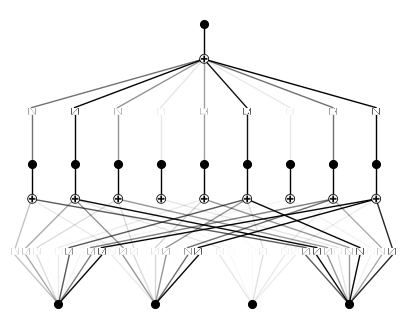

In [5]:
# plot KAN at initialization
model(dataset['train_input']);
model.plot()

In [6]:
# train the model
model.fit(dataset, opt="LBFGS", steps=100, lamb=0.01);

| train_loss: 3.60e-01 | test_loss: 6.85e-01 | reg: 3.72e+00 | : 100%|█| 100/100 [00:54<00:00,  1.84

saving model version 0.1


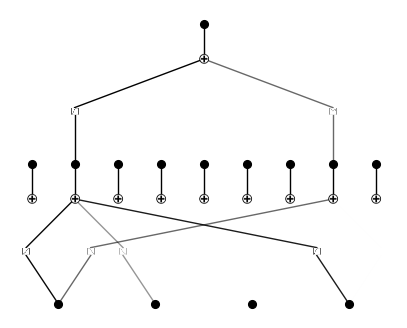

In [7]:
model.plot()

saving model version 0.2


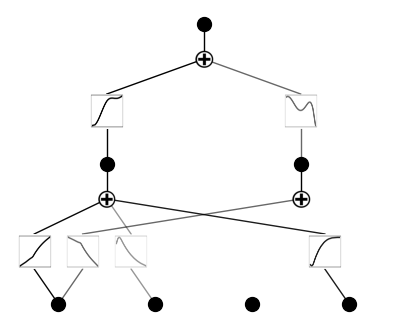

In [8]:
model = model.prune()
model.plot()

In [9]:
from sklearn.metrics import r2_score

test_pred = model(dataset['test_input']).detach().cpu().numpy()

r2 = r2_score(test_label, test_pred)

print(r2)

0.7163745052688806


In [10]:
model.fit(dataset, opt="LBFGS", steps=1000);

| train_loss: 3.54e-01 | test_loss: 4.94e-01 | reg: 5.74e+00 | : 100%|█| 1000/1000 [07:06<00:00,  2.

saving model version 0.3


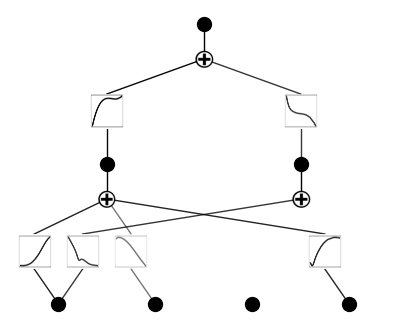

In [11]:
model.plot()

In [12]:
lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','abs']
model.auto_symbolic(lib=lib)

fixing (0,0,0) with x, r2=0.9354901687779807, c=1
fixing (0,0,1) with x, r2=0.7912616846061638, c=1
fixing (0,1,0) with x, r2=0.8030406930578287, c=1
fixing (0,1,1) with 0
fixing (0,2,0) with 0
fixing (0,2,1) with 0
fixing (0,3,0) with x, r2=0.9138305762217162, c=1
fixing (0,3,1) with 0
fixing (1,0,0) with exp, r2=0.9956545832445397, c=2
fixing (1,1,0) with x, r2=0.7210781184454124, c=1
saving model version 0.4


In [13]:
from kan.utils import ex_round

ex_round(model.symbolic_formula()[0][0],4)

C:\Users\zhang\anaconda3\envs\kanec\lib\site-packages\sympy\core\sympify.py:475: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  return sympify(float(a))


0.0226*x_1 - 0.8276*exp(-0.096*x_1 + 0.0912*x_2 - 0.1243*x_4) + 1.2367

In [14]:
from sklearn.metrics import r2_score

test_pred = model(dataset['test_input']).detach().cpu().numpy()

r2 = r2_score(test_label, test_pred)

print(r2)

0.7799873799936186
